# Training From Scratch: MNIST

* Blog [Training a Latent Diffusion Model From Scratch](https://medium.com/@geronimo7/training-a-latent-diffusion-model-from-scratch-897c7b77ece9)
* Code: https://github.com/geronimi73/Hana/blob/main/blogpost/MNIST.ipynb

In [1]:
import torch
import torch.nn.functional as F

from datasets import load_dataset
from diffusers import SanaTransformer2DModel, AutoencoderDC
from transformers import AutoModel, AutoTokenizer, GemmaTokenizerFast
from torchvision.utils import make_grid
from torchvision import transforms
import torchvision.transforms as T

dtype = torch.bfloat16
# dtype = torch.float32

device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

print(f"device: {device}")

/home/colligo/transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
def encode_prompt(prompt, tokenizer, text_encoder, max_length=50, add_special_tokens=False):
    # prompt = prompt.lower().strip()
    
    tokenizer.padding_side = "right"
    if isinstance(prompt, list):
        prompt = [p.lower().strip() for p in prompt]
    elif isinstance(prompt, str):
        prompt = prompt.lower().strip()
    else:
        raise Exception(f"Unknown prompt type {type(prompt)}")
        
    inputs = tokenizer(prompt, return_tensors="pt", padding="max_length", 
                       max_length=max_length, truncation=True, add_special_tokens=add_special_tokens).to(device)

    # print(inputs)
    
    with torch.no_grad():
        outputs = text_encoder(**inputs)    
        # 1. Start with raw Gemma output (Shape: [1, 300, 2304])
        prompt_embeds = outputs.last_hidden_state
            
    return prompt_embeds, inputs.attention_mask


def latent_to_PIL(latent, ae):
    with torch.no_grad():
        image_out = ae.decode(latent).sample.to("cpu")
    
    if image_out.size(0) == 1:
        # Single image processing
        image_out = torch.clamp_(image_out[0,:], -1, 1)
        image_out = image_out * 0.5 + 0.5
        return T.ToPILImage()(image_out.float())
    else:
        images = []
        for img in image_out:
            img = torch.clamp_(img, -1, 1)
            img = img * 0.5 + 0.5
            images.append(T.ToPILImage()(img.float()))
        return images


def PIL_to_latent(images, ae):
    transform = T.Compose([
        T.ToTensor(),
        T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        lambda x: x.to(dtype=ae.dtype)
    ])

    if not isinstance(images, (list, tuple)): images = [images]
    
    images_tensors = torch.cat([transform(image)[None] for image in images])
    
    with torch.no_grad():
        latent = ae.encode(images_tensors.to(ae.device))
    return latent.latent


def add_random_noise(latents, timesteps=1000):
    # batch size
    bs = latents.size(0)

    # gaussian noise
    noise = torch.randn_like(latents)

    # normal distributed sigmas
    sigmas = torch.randn((bs,)).sigmoid().to(latents.device)
    
    timesteps = (sigmas * timesteps).to(latents.device)   # yes, `timesteps = sigmas * 1000`, let's keep it simple
    sigmas = sigmas.view([latents.size(0), *([1] * len(latents.shape[1:]))])
    
    latents_noisy = (1 - sigmas) * latents + sigmas * noise # (1-noise_level) * latent + noise_level * noise

    # max_timesteps=1000
    
    # # 1. Sample UNIFORMLY between 0 and 1
    # # This ensures the model sees clean data, pure noise, and everything between
    # sigmas = torch.rand((bs,), device=device, dtype=dtype)
    
    # # 2. Scale for the Transformer (0 to 1000)
    # timesteps = sigmas * max_timesteps
    
    # # 3. Reshape for broadcasting [batch, 1, 1, 1]
    # sigmas_spatial = sigmas.view(bs, 1, 1, 1)
    
    # # 4. Standard Flow Matching Linear Interpolation
    # noise = torch.randn_like(latents)
    # latents_noisy = (1 - sigmas_spatial) * latents + sigmas_spatial * noise

    return latents_noisy.to(latents.dtype), timesteps, noise

## Original MNIST dataset

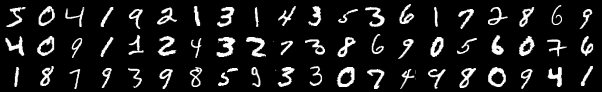

In [31]:
ds = load_dataset("ylecun/mnist")

grid=make_grid([transforms.ToTensor()(i) for i in ds["train"][:60]["image"]], nrow=20)
grid=transforms.ToPILImage()(grid)
grid

In [32]:
img_orig = ds["train"][0]["image"]
print(img_orig.size)
img_orig

(28, 28)


32px


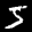

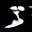

64px


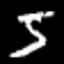

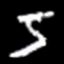

96px


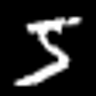

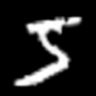

128px


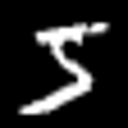

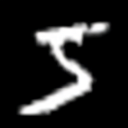

In [33]:
# original mnist datsset
for dim in [32, 64, 96, 128]:
    print(f"{dim}px")
    img = img_orig.convert('RGB').resize((dim, dim))
    img = img
    display(img)
    display(latent_to_PIL(PIL_to_latent(img, vae), vae))

## Set up Diffusion Transformer (DiT)

In [3]:

config = SanaTransformer2DModel.load_config(
    "Efficient-Large-Model/Sana_600M_1024px_diffusers",
    subfolder="transformer"
)

# ModernBERT embeddings dimension
config["caption_channels"] = 768

config["num_layers"] = 12 # vs 28 in full Sana

# hidden size of 384 (6x64) vs 1152 in full Sana
config["num_attention_heads"] = 6
config["attention_head_dim"] = 64

config["cross_attention_dim"] = 384
config["num_cross_attention_heads"] = 6

transformer = SanaTransformer2DModel.from_config(config).to(dtype).to(device)
print(f"Transformer parameters: {sum(p.numel() for p in transformer.parameters()) / 1e6:.2f}M")
# transformer.to(dtype).to(device)


Transformer parameters: 30.22M


#### This Diffusion Transformer (DiT) is quite small, just 30.2 million parameters

In [4]:
te_repo = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(te_repo, torch_dtype=dtype)
text_encoder = AutoModel.from_pretrained(te_repo, torch_dtype=dtype, attn_implementation="sdpa").to(device)

vae = AutoencoderDC.from_pretrained(
    "Efficient-Large-Model/Sana_600M_1024px_diffusers", 
    subfolder="vae", 
    torch_dtype=dtype
).to(device)


## Load latent MNIST dataset encoded by Geronimo

In [Training a Latent Diffusion Model From Scratch](https://medium.com/@geronimo7/training-a-latent-diffusion-model-from-scratch-897c7b77ece9):

#### Latent Dataset

To speed up training, Geronimo preprocessed all images beforehand. Instead of encoding images on-the-fly during training (which is slow and memory-heavy), I pre-encoded all 70,000 MNIST images into latents and stored them in a HuggingFace dataset.


In [5]:
ds = load_dataset("g-ronimo/MNIST_64px-latents_dc-ae-f32c32-sana-1.0")

# inspect first sample
latent = torch.Tensor(ds["train"][0]["latent"])
print(latent.shape)
# latent_to_PIL(latent.to(dtype).to(device), vae)

torch.Size([1, 32, 2, 2])


### adding noise on latent

tensor([0.])


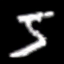

tensor([0.1000])


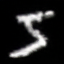

tensor([0.2500])


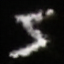

tensor([0.5000])


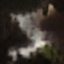

tensor([0.7500])


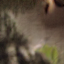

tensor([1.])


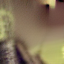

In [11]:
# gaussian noise
noise = torch.randn_like(latent)

# noise level (strength), float between 0 and 1 
for sigma in [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]:
    sigma = torch.Tensor([sigma])

    # (1-sigma) * latent + sigma * noise
    latent_noisy = (1 - sigma) * latent * vae.config["scaling_factor"] + sigma * noise

    print(sigma)
    display(
        latent_to_PIL(latent_noisy.to(dtype).to(device) / vae.config["scaling_factor"], vae)
    )

## Denoising Process

Adding noise and then one-time denoising

In [12]:
# NOTE here ds is MNIST dataset from Geronimo

# Load a sample
sample = ds["train"][0]
    
# Label, e.g. "5"
label = sample["label"]

# Encode the label 
prompt_encoded, prompt_atnmask = encode_prompt(str(label), tokenizer, text_encoder)


# print(prompt_encoded)

# Get the preprocessed Latent
latent = torch.Tensor(sample["latent"]).to(dtype).to(device)

# print(latent)
    
# Scale latent and a random amount of noise
latent = latent * vae.config["scaling_factor"]
latents_noisy, timestep, noise = add_random_noise(latent)
    
# Get a noise prediction out of the model
noise_pred = transformer(
    hidden_states = latents_noisy.to(dtype), 
    encoder_hidden_states = prompt_encoded, 
    encoder_attention_mask = prompt_atnmask,
    timestep=timestep, 
).sample

noise_pred.shape

torch.Size([1, 32, 2, 2])

In [13]:
# mean squared error of prediction and target
loss = F.mse_loss(noise_pred, noise - latent)

# calculate gradients
loss.backward()

optimizer = torch.optim.AdamW(transformer.parameters(), lr = 1e-3)

## Prepare Dataloader before training

In [8]:
from torch.utils.data import DataLoader

def collate(items):
    labels = [str(i["label"]) for i in items]
    prompts_emb, prompts_atnmask = encode_prompt(labels, tokenizer, text_encoder)

    latents = torch.cat(
        [torch.Tensor(i["latent"]) for i in items]
    ).to(dtype).to(device)

    return labels, prompts_emb, prompts_atnmask, latents

dataloader = DataLoader(
    ds["train"], 
    batch_size=128,
    collate_fn=collate
)

labels, prompts_emb, prompts_atnmask, latents = next(iter(dataloader))
latents.shape, prompts_emb.shape

(torch.Size([128, 32, 2, 2]), torch.Size([128, 50, 768]))

## Training DiT

The model learns to predict the velocity field of the rectified flow, which during inference gets reversed to denoise images.

NOTE here `.float()` is super important. Otherwise loss due to bfloat16 cannot inidcate decreasing. 
```
    target = (noise - latents).float()
    prediction = noise_pred.float()
```


In [27]:
dtype, device

(torch.bfloat16, 'cuda')

In [6]:
optimizer = torch.optim.AdamW(transformer.parameters(), lr = 1e-3)

0 3.572007179260254
1 3.371034860610962
2 3.0123775005340576
3 2.4294381141662598
4 2.553561210632324
5 2.5062479972839355
6 2.4500370025634766
7 2.4261176586151123
8 2.325439453125
9 2.4766478538513184
10 2.4480326175689697
11 2.1709401607513428
12 1.9867491722106934
13 1.7799954414367676
14 1.9340519905090332
15 1.8302433490753174
16 1.6781535148620605
17 1.6760334968566895
18 1.7276840209960938
19 1.717584490776062
20 1.7307991981506348
21 1.7321019172668457
22 1.6946437358856201
23 1.6552534103393555
24 1.6075750589370728
25 1.5620753765106201
26 1.6872409582138062
27 1.6361808776855469
28 1.683535099029541
29 1.6541072130203247
30 1.5883123874664307
31 1.5772202014923096
32 1.6239269971847534
33 1.5738747119903564
34 1.6025731563568115
35 1.5908880233764648
36 1.607431411743164
37 1.6518220901489258
38 1.5660033226013184
39 1.5772435665130615
40 1.5628465414047241
41 1.5552217960357666
42 1.5270440578460693
43 1.5423643589019775
44 1.5360311269760132
45 1.5010572671890259
46 1.467

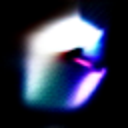

50 1.48856782913208
51 1.421932578086853
52 1.4277812242507935
53 1.448127269744873
54 1.4541124105453491
55 1.4896382093429565
56 1.4793561697006226
57 1.4661545753479004
58 1.4070905447006226
59 1.4434075355529785
60 1.4612902402877808
61 1.5197604894638062
62 1.5022406578063965
63 1.4407832622528076
64 1.481205701828003
65 1.4338555335998535
66 1.432870626449585
67 1.4830398559570312
68 1.4233310222625732
69 1.4547276496887207
70 1.4318093061447144
71 1.4041188955307007
72 1.4170361757278442
73 1.453330159187317
74 1.4324278831481934
75 1.398903250694275
76 1.3674317598342896
77 1.3745403289794922
78 1.3744069337844849
79 1.352899432182312
80 1.3996646404266357
81 1.3670077323913574
82 1.3347612619400024
83 1.359203577041626
84 1.307736873626709
85 1.316054344177246
86 1.3160549402236938
87 1.2746143341064453
88 1.2744319438934326
89 1.274436354637146
90 1.3306055068969727
91 1.3047102689743042
92 1.2814161777496338
93 1.2554960250854492
94 1.2146000862121582
95 1.2688465118408203
9

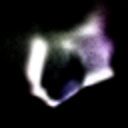

100 1.237229347229004
101 1.2348617315292358
102 1.212164282798767
103 1.211890697479248
104 1.1588118076324463
105 1.174764633178711
106 1.2033048868179321
107 1.1870462894439697
108 1.1755117177963257
109 1.2340679168701172
110 1.2331637144088745
111 1.17454195022583
112 1.1869285106658936
113 1.1676597595214844
114 1.176853895187378
115 1.1909184455871582
116 1.1008975505828857
117 1.1070404052734375
118 1.1102044582366943
119 1.0950270891189575
120 1.0846667289733887
121 1.1057260036468506
122 1.096060037612915
123 1.1079154014587402
124 1.0924384593963623
125 1.0750694274902344
126 1.0258164405822754
127 1.048954725265503
128 1.0335025787353516
129 1.0573745965957642
130 1.0378780364990234
131 1.1118478775024414
132 1.0862088203430176
133 1.0534276962280273
134 1.1218299865722656
135 1.0446113348007202
136 1.0697109699249268
137 1.0714004039764404
138 1.053821325302124
139 1.0127339363098145
140 0.9738695621490479
141 0.988114595413208
142 1.0151312351226807
143 1.0523254871368408

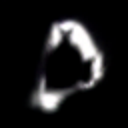

150 1.016336441040039
151 1.0448098182678223
152 0.9781074523925781
153 0.9691287279129028
154 0.9691387414932251
155 0.9975256323814392
156 0.9963243007659912
157 1.0481815338134766
158 0.9896378517150879
159 0.9046624898910522
160 0.9317797422409058
161 0.9368844628334045
162 0.9176641702651978
163 0.9899230003356934
164 0.9181340336799622
165 0.8959556818008423
166 0.9547454118728638
167 0.97625732421875
168 0.9321299195289612
169 0.9174489974975586
170 0.9283961057662964
171 0.8751263618469238
172 1.031713843345642
173 0.9808758497238159
174 0.9650375247001648
175 0.969521164894104
176 0.9659489393234253
177 0.9548444747924805
178 0.8783795833587646
179 0.9310719966888428
180 0.9501187801361084
181 0.9036742448806763
182 0.9317017793655396
183 0.9178956151008606
184 0.9159444570541382
185 0.9237290024757385
186 0.9608603715896606
187 0.9099689722061157
188 0.8679285049438477
189 0.8937991261482239
190 0.8740020990371704
191 0.9260287284851074
192 0.9211293458938599
193 0.8855264186

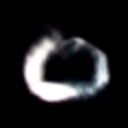

200 0.9086651802062988
201 0.8813660144805908
202 0.8948652744293213
203 0.8936266899108887
204 0.8362318873405457
205 0.8674156665802002
206 0.8614251017570496
207 0.8816155195236206
208 0.8629103899002075
209 0.8748037815093994
210 0.8131344318389893
211 0.9229365587234497
212 0.9204889535903931
213 0.8513534665107727
214 0.9092840552330017
215 0.849028468132019
216 0.8531354665756226
217 0.865009605884552
218 0.838716983795166
219 0.8088873624801636
220 0.8553341627120972
221 0.866769552230835
222 0.8265803456306458
223 0.867595374584198
224 0.8444596529006958
225 0.876947283744812
226 0.8674954771995544
227 0.8411368131637573
228 0.8664557337760925
229 0.8648743629455566
230 0.8147736191749573
231 0.7938544750213623
232 0.8688271045684814
233 0.8450919389724731
234 0.8558478951454163
235 0.8378351330757141
236 0.8231834173202515
237 0.8270848989486694
238 0.8378891944885254
239 0.8064926266670227
240 0.7952699661254883
241 0.796043872833252
242 0.8199695348739624
243 0.813450336456

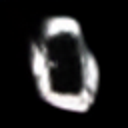

250 0.8436310291290283
251 0.8121904730796814
252 0.8311959505081177
253 0.8555575609207153
254 0.818821907043457
255 0.8119101524353027
256 0.8360152244567871
257 0.8112677335739136
258 0.7739593982696533
259 0.8131880760192871
260 0.8194970488548279
261 0.7728664875030518
262 0.807183027267456
263 0.7802149057388306
264 0.7778480052947998
265 0.7562615275382996
266 0.7865957021713257
267 0.7651211619377136
268 0.7862740755081177
269 0.8261287212371826
270 0.7960445880889893
271 0.7998969554901123
272 0.8160490989685059
273 0.7482059001922607
274 0.7829064130783081
275 0.7412241697311401
276 0.7817639112472534
277 0.8130499124526978
278 0.7895886898040771
279 0.7976411581039429
280 0.7909157276153564
281 0.7933785915374756
282 0.8044878840446472
283 0.8161988258361816
284 0.7829052209854126
285 0.8127726316452026
286 0.7709251642227173
287 0.7395663261413574
288 0.8197455406188965
289 0.8046468496322632
290 0.7888740301132202
291 0.7982349395751953
292 0.8396108746528625
293 0.8273914

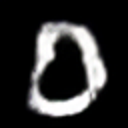

300 0.75063556432724


In [10]:
losses = []

for step, (labels, prompts_emb, prompts_atnmask, latents) in enumerate(dataloader):
    # Scale latent and a random amount of noise
    latents = latents * vae.config["scaling_factor"]
    latents_noisy, timestep, noise = add_random_noise(latents)
    
    # Get a noise prediction out of the model
    noise_pred = transformer(
        hidden_states = latents_noisy.to(dtype), 
        encoder_hidden_states = prompts_emb, 
        encoder_attention_mask = prompts_atnmask,
        timestep=timestep, 
    ).sample

    # NOTE here ".float()" is super important. Otherwise loss due to bfloat16 cannot inidcate decreasing. 
    target = (noise - latents).float()
    prediction = noise_pred.float()

    # 2. Amplify the loss
    loss = F.mse_loss(prediction, target)# * 1000
    losses.append(loss.item())
    print(step, loss.item())
    
    optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(transformer.parameters(), max_norm=1.0)
    optimizer.step()

    if (step + 1) % 50 == 0:
        display(
            generate(
                "0",
                transformer, tokenizer, text_encoder, vae,
                latent_dim = [1, 32, 2, 2],
                num_steps = 10,
            ).resize((128, 128))
        )
    
    if step == 300:
        break

In [9]:
def generate(prompt, transformer, tokenizer, text_encoder, dcae, num_steps = 10, latent_dim = [1, 32, 8, 8], guidance_scale = None, neg_prompt = "", seed=None, max_prompt_tok=50, add_special_tokens=False):
    device, dtype = transformer.device, transformer.dtype
    do_cfg = guidance_scale is not None

    # Encode the prompt, +neg. prompt if classifier free guidance (CFG)
    prompt_encoded, prompt_atnmask = encode_prompt(
        [prompt, neg_prompt] if do_cfg else prompt, 
        tokenizer, 
        text_encoder,
        max_length = max_prompt_tok,
        add_special_tokens = add_special_tokens
    )
        
    # Divide 1000 -> 0 in equally sized steps
    timesteps = torch.linspace(1000, 0, num_steps + 1, device=device, dtype=dtype)
    
    # Noise level. 1.0 -> 0.0 in equally sized steps
    sigmas = timesteps / 1000
    
    latent = torch.randn(
        latent_dim, 
        generator=torch.manual_seed(seed) if seed else None
    ).to(dtype).to(device)
    
    for t, sigma_prev, sigma_next, steps_left in zip(
        timesteps, 
        sigmas[:-1], 
        sigmas[1:], 
        range(num_steps, 0, -1)
    ):
        t = t[None].to(device)

        # DiT predicts noise
        with torch.no_grad():
            noise_pred = transformer(
                hidden_states = torch.cat([latent] * 2) if do_cfg else latent,
                timestep = torch.cat([t] * 2) if do_cfg else t,
                encoder_hidden_states=prompt_encoded,
                encoder_attention_mask=prompt_atnmask,
                return_dict=False
            )[0]

        if do_cfg:
            noise_pred_cond, noise_pred_uncond = noise_pred.chunk(2)
            noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_cond - noise_pred_uncond)

        # Remove noise from latent
        latent = latent + (sigma_next - sigma_prev) * noise_pred 

    return latent_to_PIL(latent / dcae.config["scaling_factor"], dcae)

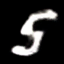

In [12]:
generate("5", transformer, tokenizer, text_encoder, vae, latent_dim = [1, 32, 2, 2], num_steps = 10)

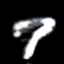

In [17]:
generate("9", transformer, tokenizer, text_encoder, vae, latent_dim = [1, 32, 2, 2], num_steps = 10)

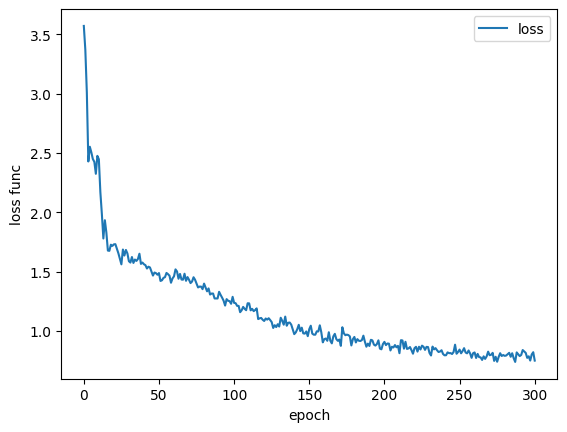

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(range(len(losses)), losses, label="loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss func")
plt.show()